In [1]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import gaussian_kde



import numpy as np
import matplotlib.pyplot as plt




In [2]:

# ============================================================
# CONFIGURATION
# ============================================================

## MAX_FILE = "nio_optimized_200_max.csv"
## MIN_FILE = "nio_optimized_200_minimize.csv"

MAX_FILE = "nio_optimized_200_max.csv"


###########################################

random_flag = False        ## Change Only this


if random_flag:
    MIN_FILE    = "random_points.csv"
    name_output = "Random"
else:
    MIN_FILE    = "nio_optimized_200_min.csv"
    name_output = "Min"


###########################################

HORIZON = 900


In [3]:

# ============================================================
# LOAD DATA
# ============================================================

max_df = pd.read_csv(MAX_FILE)
min_df = pd.read_csv(MIN_FILE)



In [4]:

max_df


,Time_steps,point_id,x0,y0,z0
0,300,0,4.334419,9.861786,13.155937
1,300,1,19.695328,0.779478,9.954550
2,300,2,17.409600,0.479961,17.064210
3,300,3,-13.649555,-11.529343,25.880936
4,300,4,-17.842530,-2.126389,24.121515
...,...,...,...,...,...
3995,1300,995,-17.978146,-24.966349,45.860374
3996,1300,996,9.016561,-9.979977,45.979233
3997,1300,997,-9.817795,21.351670,28.764898
3998,1300,998,11.516464,-19.466331,38.763220


In [5]:

min_df


,Time_steps,point_id,x0,y0,z0
0,300,0,-16.866148,7.687355,44.039280
1,300,1,-15.959354,11.692524,40.677410
2,300,2,-18.840310,9.322880,13.501758
3,300,3,16.939450,14.055645,10.128780
4,300,4,-7.871334,-17.974750,40.722477
...,...,...,...,...,...
3995,1300,995,2.783924,9.075871,6.339331
3996,1300,996,14.241150,24.845749,40.504356
3997,1300,997,15.099567,-17.586386,18.250864
3998,1300,998,-16.977428,18.135452,47.161160


In [6]:

time_col = [c for c in max_df.columns if "time" in c.lower()][0]


In [7]:

time_col


'Time_steps'

In [8]:

max_data = max_df[max_df[time_col] == HORIZON].copy()


In [9]:

if random_flag == False:
    min_data = min_df[min_df[time_col] == HORIZON].copy()
else:
    min_data = min_df.copy()   


In [10]:

max_data


,Time_steps,point_id,x0,y0,z0
2000,900,0,5.537384,7.429584,17.617476
2001,900,1,15.820267,-28.928047,3.342888
2002,900,2,-14.631885,4.445206,46.085743
2003,900,3,5.562977,-11.697836,9.759507
2004,900,4,10.387220,-10.459404,42.008293
...,...,...,...,...,...
2995,900,995,-15.646301,-14.692164,9.030634
2996,900,996,1.320507,0.247578,33.008760
2997,900,997,15.422245,-24.831097,46.137160
2998,900,998,-5.499721,0.647278,44.645885


In [11]:

min_data


,Time_steps,point_id,x0,y0,z0
2000,900,0,-18.988825,-23.030502,31.280739
2001,900,1,-11.308835,-22.894430,18.293621
2002,900,2,-4.381627,-1.826294,7.003131
2003,900,3,-16.373875,-18.380540,14.244254
2004,900,4,-11.266871,-21.222012,14.816197
...,...,...,...,...,...
2995,900,995,-11.037484,0.764620,12.615928
2996,900,996,18.658176,17.698730,15.561515
2997,900,997,-15.390007,18.603573,17.452955
2998,900,998,-13.754414,-26.605196,32.172560


In [12]:

print("\nLoaded Data")
print("----------------------------")
print("Max-sensitive points :", len(max_data))
print("Min-sensitive points :", len(min_data))



Loaded Data
----------------------------
Max-sensitive points : 1000
Min-sensitive points : 1000


In [13]:

# =====================================================
# LORENZ SYSTEM
# =====================================================

sigma = 10.0
beta  = 8.0 / 3.0
rho   = 28.0

dt = 0.01


In [14]:

def lorenz_step(x):

    dx = sigma * (x[1] - x[0])

    dy = x[0] * (rho - x[2]) - x[1]

    dz = x[0] * x[1] - beta * x[2]

    return x + dt * np.array([dx, dy, dz])



In [15]:

def simulate_lorenz(x0, steps=1000):

    x = np.array(x0, dtype=np.float64)

    traj = np.zeros((steps + 1, 3))

    traj[0] = x

    for i in range(steps):

        x = lorenz_step(x)

        traj[i + 1] = x

    return traj


In [16]:

# =====================================================
# NIO SCORE
# SAME IDEA AS PAPER A LOSS
# =====================================================

def nio_divergence_score(
    x0,
    delta=1e-6,
    steps=1000
):

    x1 = np.array(x0)

    x2 = np.array(x0)

    x2[0] += delta

    traj1 = simulate_lorenz(x1, steps)

    traj2 = simulate_lorenz(x2, steps)

    separation = np.linalg.norm(
        traj2 - traj1,
        axis=1
    )

    score = np.sum(separation**2)

    return score


In [17]:

# =====================================================
# FINITE TIME LYAPUNOV
# =====================================================

def finite_time_lyapunov(
    x0,
    delta=1e-6,
    steps=900
):

    x1 = np.array(x0)

    x2 = np.array(x0)

    x2[0] += delta

    traj1 = simulate_lorenz(x1, steps)

    traj2 = simulate_lorenz(x2, steps)

    d0 = np.linalg.norm(
        traj2[0] - traj1[0]
    )

    dT = np.linalg.norm(
        traj2[-1] - traj1[-1]
    )

    dT = max(dT, 1e-12)

    lam = np.log(dT / d0) / (steps * dt)

    return lam


In [18]:

# =====================================================
# RANDOM BASELINE
# =====================================================

def generate_random_points(n=1000):

    pts = np.zeros((n,3))

    pts[:,0] = np.random.uniform(-20,20,n)

    pts[:,1] = np.random.uniform(-30,30,n)

    pts[:,2] = np.random.uniform(0,50,n)

    return pts





In [19]:

random_points = generate_random_points(1000)


In [20]:

random_points.shape


(1000, 3)

In [21]:

## lumpy = df.iloc[:, :3]

max_data_np = max_data.iloc[:, 2:5].to_numpy()


In [22]:

print(max_data_np.shape)
print(max_data_np)


(1000, 3)
[[  5.537384     7.4295845   17.617476  ]
 [ 15.820267   -28.928047     3.3428879 ]
 [-14.631885     4.4452057   46.085743  ]
 ...
 [ 15.422245   -24.831097    46.13716   ]
 [ -5.4997215    0.64727783  44.645885  ]
 [ -7.577379    -9.92617      8.282229  ]]


In [23]:

max_data_np.shape


(1000, 3)

In [24]:

min_data_np = min_data.iloc[:, 2:5].to_numpy()


In [25]:

print(min_data_np.shape)
print(min_data_np)


(1000, 3)
[[-18.988825  -23.030502   31.280739 ]
 [-11.308835  -22.89443    18.293621 ]
 [ -4.381627   -1.826294    7.003131 ]
 ...
 [-15.390007   18.603573   17.452955 ]
 [-13.754414  -26.605196   32.17256  ]
 [ -7.6997128  17.04406    37.60183  ]]


In [26]:

high_points = max_data_np
low_points  = min_data_np


In [27]:

# =====================================================
# COMPUTE FTLE
# =====================================================

print("Computing FTLE values...")

high_ftle = []
low_ftle  = []
rand_ftle = []

for p in high_points:
    
    high_ftle.append(
        finite_time_lyapunov(p)
    )

for p in low_points:

    low_ftle.append(
        finite_time_lyapunov(p)
    )

for p in random_points:

    rand_ftle.append(
        finite_time_lyapunov(p)
    )

high_ftle = np.array(high_ftle)
low_ftle  = np.array(low_ftle)
rand_ftle = np.array(rand_ftle)


Computing FTLE values...


In [28]:


print("\n==============================")
print("FINITE TIME LYAPUNOV RESULTS")
print("==============================")

print(
    "NIO MAX  Mean FTLE:",
    np.mean(high_ftle)
)

print(
    "NIO MIN  Mean FTLE:",
    np.mean(low_ftle)
)

print(
    "Random   Mean FTLE:",
    np.mean(rand_ftle)
)
print()





FINITE TIME LYAPUNOV RESULTS
NIO MAX  Mean FTLE: 0.8549026707706987
NIO MIN  Mean FTLE: 0.7625244651238912
Random   Mean FTLE: 0.9209573780062962



In [29]:

print(
    "NIO MAX  Std:",
    np.std(high_ftle)
)

print(
    "NIO MIN  Std:",
    np.std(low_ftle)
)

print(
    "Random   Std:",
    np.std(rand_ftle)
)


NIO MAX  Std: 0.21343264182765365
NIO MIN  Std: 0.19208175205096545
Random   Std: 0.1847256874688394


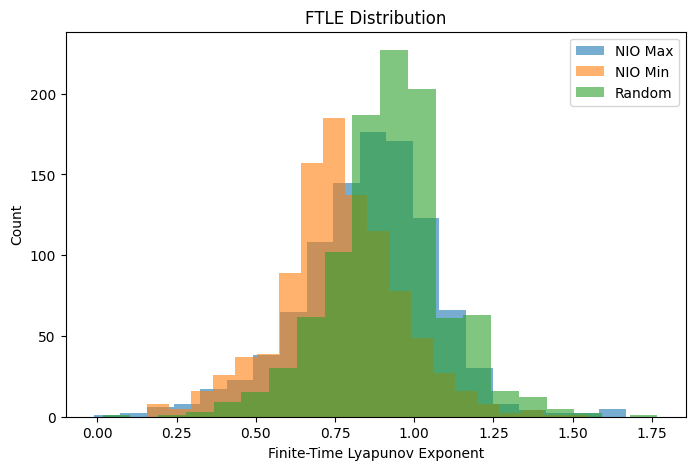

In [30]:


# =====================================================
# HISTOGRAM
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    high_ftle,
    bins=20,
    alpha=0.6,
    label="NIO Max"
)

plt.hist(
    low_ftle,
    bins=20,
    alpha=0.6,
    label="NIO Min"
)

plt.hist(
    rand_ftle,
    bins=20,
    alpha=0.6,
    label="Random"
)

plt.xlabel("Finite-Time Lyapunov Exponent")
plt.ylabel("Count")

plt.title("FTLE Distribution")

plt.legend()

plt.show()




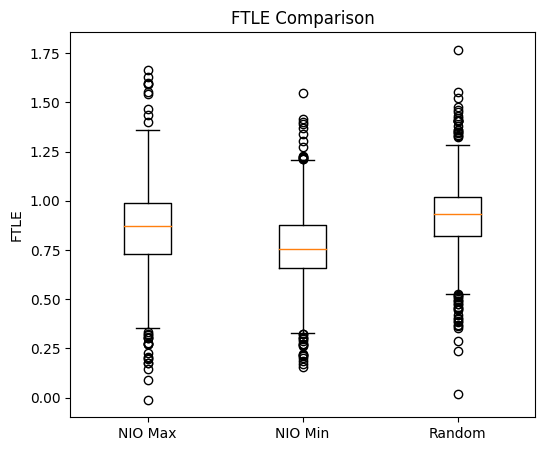

In [31]:


# =====================================================
# BOXPLOT
# =====================================================

plt.figure(figsize=(6,5))

plt.boxplot(
    [
        high_ftle,
        low_ftle,
        rand_ftle
    ],
    labels=[
        "NIO Max",
        "NIO Min",
        "Random"
    ]
)

plt.ylabel("FTLE")

plt.title("FTLE Comparison")

plt.show()



Computing NIO scores...

Correlation (NIO Score vs FTLE): 0.08138064219525702


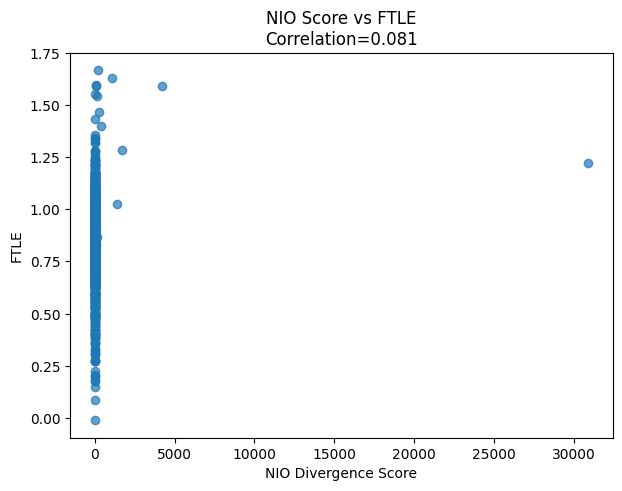

In [32]:



# =====================================================
# CORRELATION WITH NIO SCORE
# =====================================================

print("\nComputing NIO scores...")

high_scores = []

for p in high_points:

    high_scores.append(
        nio_divergence_score(p)
    )

high_scores = np.array(high_scores)

corr = np.corrcoef(
    high_scores,
    high_ftle
)[0,1]

print()

print(
    "Correlation (NIO Score vs FTLE):",
    corr
)

plt.figure(figsize=(7,5))

plt.scatter(
    high_scores,
    high_ftle,
    alpha=0.7
)

plt.xlabel("NIO Divergence Score")

plt.ylabel("FTLE")

plt.title(
    f"NIO Score vs FTLE\nCorrelation={corr:.3f}"
)

plt.show()



In [33]:



# =====================================================
# MOST CHAOTIC POINT
# =====================================================

idx = np.argmax(high_ftle)

print("\nMost Chaotic NIO Point")

print(
    "Initial Condition:",
    high_points[idx]
)

print(
    "FTLE:",
    high_ftle[idx]
)

print(
    "NIO Score:",
    high_scores[idx]
)




Most Chaotic NIO Point
Initial Condition: [-10.055932 -26.251009  48.435757]
FTLE: 1.6665107015138587
NIO Score: 207.81527107570454


In [34]:

high_scores = []
for p in high_points:

    high_scores.append(
        nio_divergence_score(p)
    )
high_scores = np.array(high_scores)

######

low_scores = []
for p in low_points:

    low_scores.append(
        nio_divergence_score(p)
    )
low_scores = np.array(low_scores)

######

random_scores = []
for p in random_points:

    random_scores.append(
        nio_divergence_score(p)
    )
random_scores = np.array(random_scores)

#######



In [35]:


print("high ", high_scores.mean() )
print("low ", low_scores.mean() )
print("random", random_scores.mean() )


high  41.108145478974436
low  1.4660260275698689
random 47.36074541201708
